In [44]:
import pandas as pd 

part1 = pd.read_csv("HarrisPartI.csv")
part3 = pd.read_csv("HarrisPartIII.csv")

print("Part I rows and columns:", part1.shape)
print("Part III rows and columns:", part3.shape)

print("Part I column names:", part1.columns.tolist())
print("Part III column names", part3.columns.tolist())

print("\n Missing values in Part I: ")
print(part1.isna().sum())

print("\n Missing values in Part III:")
print(part3.isna().sum())

print("\n Repeated IDs in Part I: ", part1["ID"].duplicated().sum())
print("Repeated IDs in Part III", part3["ID"].duplicated().sum())

ids1 = set(part1["ID"])
ids3 = set(part3["ID"])

print("IDs in Part I but not Part III:", ids1 - ids3)
print("IDs in Part III but not Part I:", ids3 - ids1)
print("Clusters with v_LSR:", part3["v_LSR"].notna().sum())

Part I rows and columns: (157, 11)
Part III rows and columns: (157, 13)
Part I column names: ['ID', 'Name', 'RA', 'DEC', 'L', 'B', 'R_Sun', 'R_gc', 'X', 'Y', 'Z']
Part III column names ['ID', 'v_r', 'v_r_e', 'v_LSR', 'sig_v', 'sig_v_e', 'c', 'r_c', 'r_h', 'mu_V', 'rho_0', 'lg_tc', 'lg_th']

 Missing values in Part I: 
ID         0
Name     106
RA         0
DEC        0
L          0
B          0
R_Sun      0
R_gc       0
X          0
Y          0
Z          0
dtype: int64

 Missing values in Part III:
ID          0
v_r        14
v_r_e      14
v_LSR      14
sig_v      95
sig_v_e    95
c           1
r_c         1
r_h         5
mu_V       14
rho_0      14
lg_tc      14
lg_th       2
dtype: int64

 Repeated IDs in Part I:  0
Repeated IDs in Part III 0
IDs in Part I but not Part III: set()
IDs in Part III but not Part I: set()
Clusters with v_LSR: 143


In [45]:
marged = part1.merge(
    part3,
    on="ID",
    how="inner",
    validate="one_to_one"
)

print("Rows after joining: ", len(marged))
print("Unique cluster IDs: ", marged["ID"].nunique())
print("Clusters with v_LSR: ", marged["v_LSR"].notna().sum())

display(marged[["ID", "L", "B", "v_r", "v_LSR"]].head())


Rows after joining:  157
Unique cluster IDs:  157
Clusters with v_LSR:  143


,ID,L,B,v_r,v_LSR
0,NGC 104,305.89,-44.89,-18.0,-26.7
1,NGC 288,152.30,-89.38,-45.4,-51.9
2,NGC 362,301.53,-46.25,223.5,214.0
3,Whiting 1,161.22,-60.76,-130.6,-138.1
4,NGC 1261,270.54,-52.12,68.2,54.9


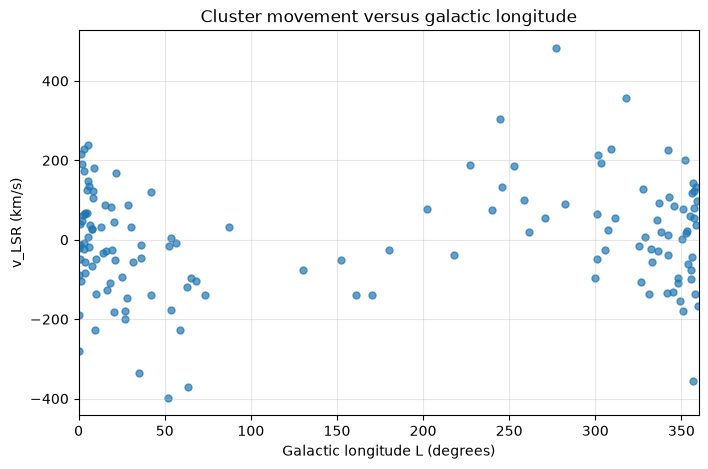

Clusters plotted:  143


In [46]:
import matplotlib.pyplot as plt

plot_data = marged.dropna(subset=["L", "v_LSR"])

plt.figure(figsize=(8,5))
plt.scatter(plot_data["L"], plot_data["v_LSR"], s=25, alpha=0.7)
plt.ylabel("v_LSR (km/s)")
plt.xlabel("Galactic longitude L (degrees)")
plt.title("Cluster movement versus galactic longitude")
plt.xlim(0, 360)
plt.grid(alpha=0.3)

plt.show()
print("Clusters plotted: ", len(plot_data))

In [47]:
left_out_lines = marged[marged[["L", "v_LSR"]].isna().any(axis=1)]

print("Left out clusters were: ", len(left_out_lines))
print("The ones with missing L: ", left_out_lines["L"].isna().sum())
print("Missing v_LSR: ", left_out_lines["v_LSR"].isna().sum())
display(left_out_lines[["ID", "L", "v_LSR"]])

Left out clusters were:  14
The ones with missing L:  0
Missing v_LSR:  14


,ID,L,v_LSR
13,Ko 2,195.12,NaN
16,E 3,292.27,NaN
20,Ko 1,260.99,NaN
31,AM 4,320.28,NaN
42,BH 176,328.41,NaN
53,1636-283,351.91,NaN
57,FSR 1735,339.19,NaN
101,Djorg 2,2.77,NaN
103,Terzan 10,4.49,NaN
111,2MS-GC01,10.48,NaN


The joined Harris data contains 157 clusters. All 157 have a value for the Galactic longitude ('L') but 14 of them do not have a measured ('v_LSR'). For the longitude versus movement graph, I used the 143 clusters with both values.

I left the 14 clusters without 'v_LSR' out of this comparison. I did not treat their missing movement values as zero. THis means the graph describes the 143 clusters with available measurements, not necessarily every cluster in the catalogue.

In [48]:
summary_data = plot_data.copy()

summary_data["L_group"] = pd.cut(
    summary_data["L"] % 360,
    bins=range(0, 361, 60),
    right=False
)

summary = summary_data.groupby("L_group", observed=False)["v_LSR"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
)

display(summary)

,count,mean,median,std
L_group,,,,
"[0, 60)",67,-15.337313,-13.20,134.096270
"[60, 120)",6,-132.900000,-111.30,131.233883
"[120, 180)",4,-101.575000,-107.15,44.458773
"[180, 240)",4,50.325000,25.70,105.864674
"[240, 300)",10,135.000000,95.25,160.584329
"[300, 360)",52,15.542308,18.50,128.314215


I split the 143 clusters with measured 'v_LSR' into six longitude sections. The averages are negative from 0 to 180 and the positive from 180 to 360. The middle values show the same broad change.

However, the sections do not contain equal number of clusters. The 0-60 section has 67 and the 300-360 one has 52. Most other sections have bettern 4-10. In the two larger sections, the averages are close to zero compared with large spread of individual speeds. THe scatter graph also shows that clusters at 
similar longitudes can actually have very differet speeds.

The averages change sign across longitude, but the large spread means I cannot identify two clear moving groups from this comparison. 'v_LSR only really tells us the measured movement to or away from us after we correct for the sun's local movement. The direction we view each cluster may affect our pattern. Its not really possible to work out a clusters full path or its origin from this graph alone.

Also, the average v_LSR changes sign across the longitude sections but the movement values within those sections are widely spread and overlap way too much. Therefore  this first comparison does not really give us clear evidence of two seperate groups or establish how they orbit the milky way.

# What we are trying to find

I want to find the clusters with unusually large measured movement towards or away from us. Not really trying to prove if the clusters have unusual orbits or came from another galaxy but rather just make a short list to inspect.

#### Flagging rule

I will use the 143 clusters that have a measured 'v_LSR'. I will take the absolute value of each 'v_LSR', so a large negative value and a large positive value are treated equally.

Before looking at the cluster names, I will set the cutoff at the 90th percentile of these absolute values. I will flag every cluster whose absolte 'v_LSR' is at or above that cutoff. This should select 
roughly the highest 10% although the exact number may change if clusters share the cutoff value.

I will not replace the missing cluster v_LSR values. THose 14 clusters will remain where they are.

#### Why I chose this rule 

This gives me one clear rule that I can apply to every cluster in the usable sample. It looks at both 
the strongly positive and strongly negatve values instead of ignoring one direction. It also gives me a 
manageable number of clusters to check against the original data.

The 10% cutoff is a choce for exploring the data, not a known physical boundary. Being flagged means the cluster has an extreme compared to the sample. Not that it moves different from the Milky ways 
normal rotation.

#### How I will check each flagged cluster

I will make a list showing the cluster ID, 'v_LSR', its absolute value , and its measured uncertainty ('v_r_e'). I will check the ID and movement value against Harris Part III.

I will also look at the clusters position using 'L', 'B', 'Z', and 'R_gc' from Harris Part I. These 
values might help me udnerstand the cluster but they will not solve the motion problem.

I will not use 'sig_v' as the uncertainty in 'v_LSR' because 'sig_v' describes movement of stars inside 
a cluster.

#### Checkig if the rule is fragile

I will repeat the selection using the highest 5% and the highest 15% of the absolute v_LSR values. If a cluster appears only when I make a small change to the cutoff, I will describe it as a less certain candidate. I will also check whether a flagged value has a large uncertainty or incorrect match between the Harris files.

#### What I can conclude

This method can identify clusters with extreme measured movement towards or away from us that deserve a closer look. It can't really tell me ther full path or where they formed. Later, I can compare them with age metallicity and see whether different clues point to same cluster.

In [49]:
# we start with the 143 clusters that have L and v_LSR

candidates_data = plot_data.copy()

candidates_data["abs_v_LSR"] = candidates_data["v_LSR"].abs()

# we flag the highest 10% of absolute v_LSR values
cutoff = candidates_data["abs_v_LSR"].quantile(0.90)
flagged = candidates_data[candidates_data["abs_v_LSR"] >= cutoff]
flagged = flagged.sort_values("abs_v_LSR", ascending=False)

print("Clusters checked: ", len(candidates_data))
print("90-th percentile cutoff (km/s): ", cutoff)
print("Clusters flagged: ", len(flagged))

display(flagged[
            ["ID", "v_LSR", "abs_v_LSR", "v_r_e", "L", "B", "Z", "R_gc"]
])

Clusters checked:  143
90-th percentile cutoff (km/s):  214.72
Clusters flagged:  15


,ID,v_LSR,abs_v_LSR,v_r_e,L,B,Z,R_gc
18,NGC 3201,482.9,482.9,0.2,277.23,8.64,0.7,8.8
148,NGC 6934,-398.5,398.5,1.6,52.10,-18.89,-5.1,12.8
150,NGC 7006,-371.3,371.3,0.4,63.77,-19.41,-13.7,38.5
48,NGC 6101,357.0,357.0,1.7,317.74,-15.82,-4.2,11.2
92,Djorg 1,-355.0,355.0,3.6,356.69,-2.47,-0.6,5.7
149,NGC 6981,-336.2,336.2,3.7,35.16,-32.68,-9.2,12.9
9,NGC 1851,303.8,303.8,0.6,244.51,-35.03,-6.9,16.6
65,NGC 6287,-279.1,279.1,3.5,0.13,11.02,1.8,2.1
71,NGC 6333,239.8,239.8,7.0,5.54,10.71,1.5,1.7
28,NGC 5139,228.9,228.9,0.1,309.10,14.97,1.3,6.4


In [50]:
for highest_fraction in [0.05, 0.10, 0.15]:
    threshold = candidates_data["abs_v_LSR"].quantile(1 - highest_fraction)
    selected = candidates_data[candidates_data["abs_v_LSR"] >= threshold]

    print(
        f"Highest {highest_fraction:.0%}: "
        f"{len(selected)} clusters; "
        f"cutoff = {threshold:.1f} km/s"
    )
    print(selected["ID"].tolist())
    print()

Highest 5%: 8 clusters; cutoff = 275.2 km/s
['NGC 1851', 'NGC 3201', 'NGC 6101', 'NGC 6287', 'Djorg 1', 'NGC 6934', 'NGC 6981', 'NGC 7006']

Highest 10%: 15 clusters; cutoff = 214.7 km/s
['NGC 1851', 'NGC 3201', 'NGC 5139', 'NGC 6101', 'NGC 6205', 'NGC 6287', 'NGC 6333', 'Djorg 1', 'NGC 6528', '2MS-GC02', 'NGC 6584', 'NGC 6681', 'NGC 6934', 'NGC 6981', 'NGC 7006']

Highest 15%: 22 clusters; cutoff = 188.1 km/s
['NGC 362', 'NGC 1851', 'NGC 1904', 'NGC 3201', 'NGC 4833', 'NGC 5139', 'NGC 6101', 'NGC 6144', 'NGC 6205', 'NGC 6287', 'NGC 6333', 'Pal 6', 'Djorg 1', 'NGC 6535', 'NGC 6528', '2MS-GC02', 'NGC 6558', 'NGC 6584', 'NGC 6681', 'NGC 6934', 'NGC 6981', 'NGC 7006']



#### Does the candidates list change when I change the cutoff?
I repeated the selection using 5, 10 and 15% highest of absolute v_LSR. That got us 8, 15 and 22 clusters 
respectively. All the clusters in the 5% are also in the 10% list. The shortlist depends on partly 
where set the cutoff

#### Which flags neeed more caution?

The 8 clusters that remain flagged at the stricter 5% cutoff are the clearest **speed extreme under this rule**. The other 7 in my main 10% are less extreme; this does not make them incorrect results. 

Three clusters really need care cuz the 10% cutoff of 214.72. NGC 6528 is only 0.18 km/s above it, NGC 6584 is 10.18 km/s above it, and 2MS-GC02 is 12.68 km/s above it. Each gap is smaller than the clusters 
quoted 'v_r_e'. Their includion could be changed when we think about uncertainty.

The 15 flagged IDs and their displayed values were cross-checked against Harris Parts I and III; the IDs and values match, and none of these displayed fields is missing.

Once again, these clusters just tell us about the speed based shortlist, not the confidence that a cluster came from a different galaxy. With v_LSR, I cant really judge their full origins.

## Movement Result

### What I did

I joined Harris Part I and III by cluster ID and checked that the join kept all 157 clusters. For the movement comparison, I used the 143 clusters with both longitude ('L') and measured 'v_LSR', so I did not treat their missing values as zero.

### Figure and main result

My scatter graph shows v_LSR against galactic longitude. Clusters at similar longitude can have very different measured speeds. Although the averages in the six longitude sections change sign, their values overlap widely, so I cannot identify two clear moving groups from this graph.

### Clusters we flagged for closer inspection

I flagged clusters in the highest 10% of absolute v_LSR. The cutoff is 214.72 km/s, giving 15 clusters. The output above lists each ID, speed, quoted radial speed uncertainty and position

Eight of the 15 remain flagged with the stricker highest-5% rule. NGC 6584, and 2MS-GC02 need extra caution cuz they are way too close to the cutoff. cutoff is just a rule not a forced boundary.

### what this cannot show 

v_LSR just gives us movement towards or away from us after a correction for the Sun's local movement. It does not give us the clusters full path around the milky way. A large value cannot show that a cluster formed in anothe galacy. Age and metallicity may provide another clue when I compare the results.


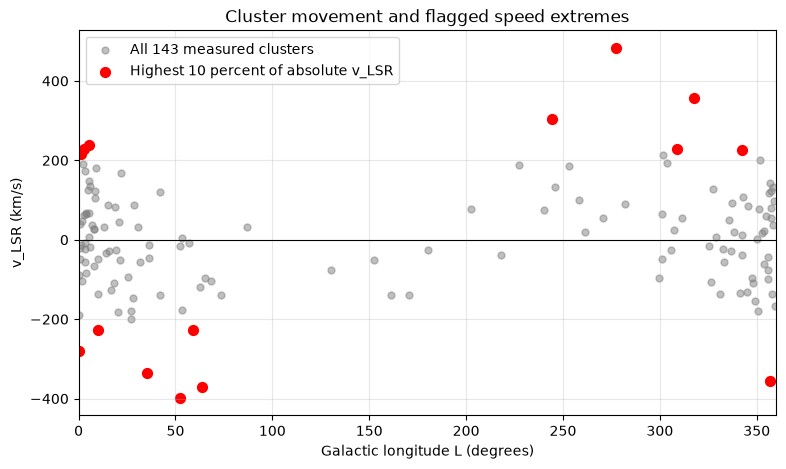

In [51]:
plt.figure(figsize=(9,5))

plt.scatter(
    plot_data["L"], plot_data["v_LSR"],
    color="grey", alpha=0.5, s=25,
    label="All 143 measured clusters"
)

plt.scatter(
    flagged["L"], flagged["v_LSR"],
    color="red", s=50,
    label="Highest 10 percent of absolute v_LSR"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Galactic longitude L (degrees)")
plt.ylabel("v_LSR (km/s)")
plt.title("Cluster movement and flagged speed extremes")
plt.xlim(0, 360)
plt.legend()
plt.grid(alpha=0.3)
plt.show()